# 🚢 Titanic Dataset — Exploratory Data Analysis

### Data Science with Python Internship — Task 2

**Objective:**  
To analyze the Titanic passenger dataset, clean the data, identify
patterns in passenger survival, and communicate insights through
effective data visualizations.

**Tools & Technologies:**  
Python | Pandas | NumPy | Matplotlib | Seaborn | Google Colab

**Dataset:**  
Titanic Passenger Dataset — Kaggle

## 📌 Project Overview

The Titanic dataset is one of the most widely used datasets for
learning data analysis and visualization.

This project focuses on understanding passenger survival patterns
based on important attributes such as:

- Gender
- Passenger class
- Age
- Fare
- Family information

The analysis involves data loading, data cleaning, exploratory
data analysis, visualization, and interpretation of results.

## 🎯 Objectives

The main objectives of this project are:

1. Load the Titanic dataset from Kaggle.
2. Understand the structure and characteristics of the dataset.
3. Identify and handle missing values.
4. Perform exploratory data analysis.
5. Analyze survival patterns by gender.
6. Analyze the relationship between passenger class and survival.
7. Analyze survival rates across different age groups.
8. Create meaningful visualizations.
9. Extract key insights from the analysis.
10. Summarize the findings in a clear conclusion.

In [25]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [26]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv('/content/train.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [27]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [29]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Columns in the dataset:")
print(df.columns.tolist())

Number of rows: 891
Number of columns: 12
Columns in the dataset:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [30]:
# ==========================================
# DATASET INFORMATION
# ==========================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
# ==========================================
# MISSING VALUE ANALYSIS
# ==========================================

missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[
    missing_data['Missing Values'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_data
# Fill missing Age values using the median
df['Age'] = df['Age'].fillna(df['Age'].median())
# Fill missing Embarked values using the most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [32]:
# ==========================================
# DUPLICATE CHECK
# ==========================================

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)
print("Dataset shape after cleaning:", df.shape)

df.head()


Number of duplicate rows: 0
Dataset shape after cleaning: (891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [33]:
# ==========================================
# OVERALL SURVIVAL
# ==========================================

survival_counts = df['Survived'].value_counts()

print("Survival Counts:")
print(survival_counts)
survival_percentage = df['Survived'].value_counts(normalize=True) * 100

print("Survival Percentage:")
print(survival_percentage)
overall_survival_rate = df['Survived'].mean() * 100

print(f"Overall Survival Rate: {overall_survival_rate:.2f}%")


Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64
Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
Overall Survival Rate: 38.38%


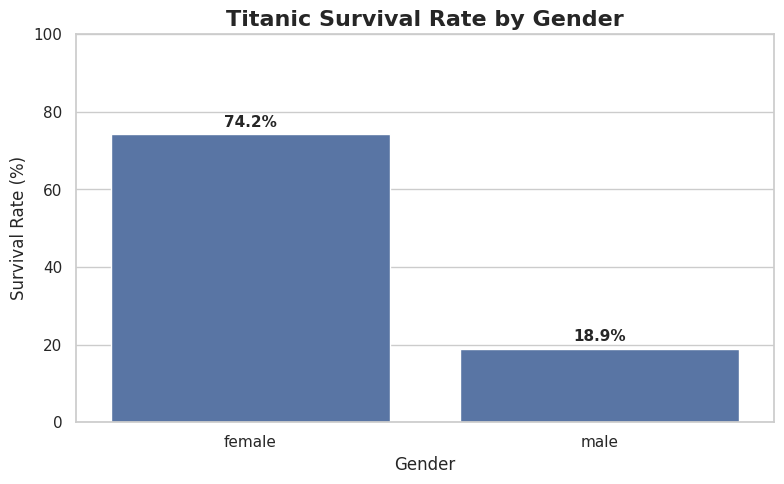

In [34]:
# ==========================================
# SURVIVAL BY GENDER
# ==========================================

gender_survival = (
    df.groupby('Sex')['Survived']
    .mean()
    .mul(100)
    .round(2)
)

gender_survival
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)

plt.title(
    'Titanic Survival Rate by Gender',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for i, value in enumerate(gender_survival.values):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()


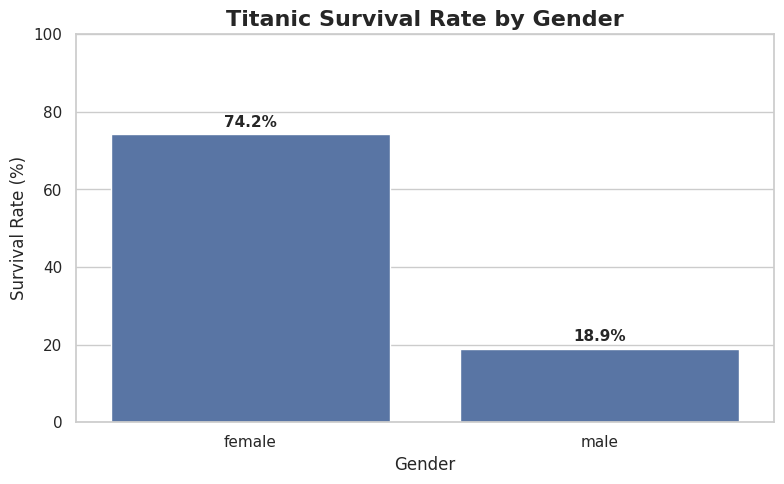

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)

plt.title(
    'Titanic Survival Rate by Gender',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for i, value in enumerate(gender_survival.values):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 🔎 Finding — Survival by Gender

The analysis shows a clear difference in survival rates between male
and female passengers. Female passengers had a substantially higher
survival rate than male passengers.

This indicates that gender was an important factor associated with
survival outcomes in the Titanic dataset.

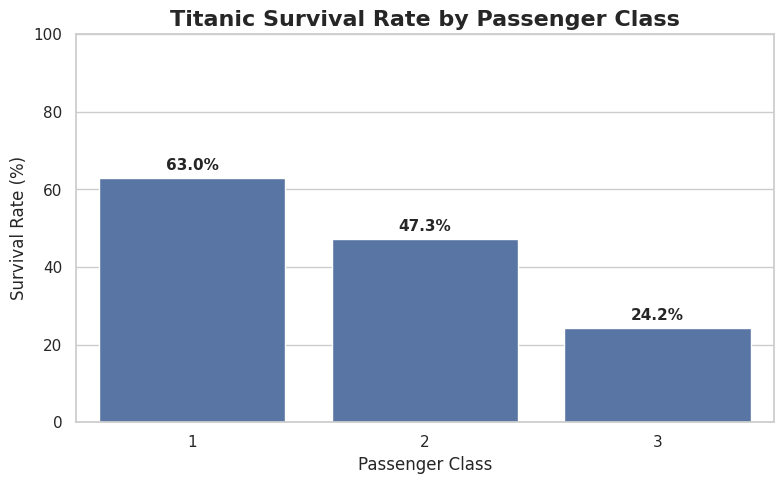

In [36]:
# ==========================================
# SURVIVAL BY PASSENGER CLASS
# ==========================================

class_survival = (
    df.groupby('Pclass')['Survived']
    .mean()
    .mul(100)
    .round(2)
)

class_survival
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=class_survival.index,
    y=class_survival.values
)

plt.title(
    'Titanic Survival Rate by Passenger Class',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for i, value in enumerate(class_survival.values):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 🔎 Finding — Survival by Passenger Class

Passenger class had a strong association with survival.

First-class passengers had the highest survival rate, while
third-class passengers had the lowest survival rate.

This suggests that socioeconomic and travel-class differences were
associated with passenger survival outcomes.

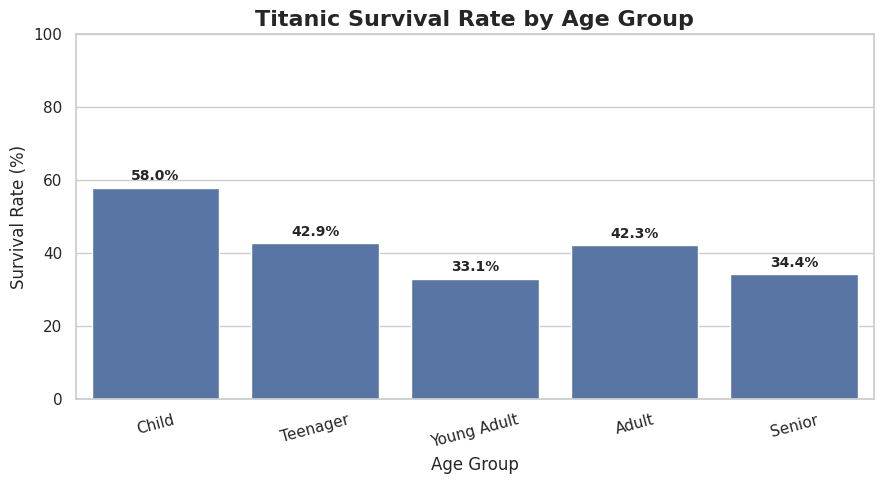

In [37]:
# ==========================================
# CREATE AGE GROUPS
# ==========================================

bins = [0, 12, 18, 30, 50, 100]

labels = [
    'Child',
    'Teenager',
    'Young Adult',
    'Adult',
    'Senior'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[['Age', 'AgeGroup']].head()
age_survival = (
    df.groupby('AgeGroup', observed=True)['Survived']
    .mean()
    .mul(100)
    .round(2)
)

age_survival
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=age_survival.index,
    y=age_survival.values
)

plt.title(
    'Titanic Survival Rate by Age Group',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for i, value in enumerate(age_survival.values):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

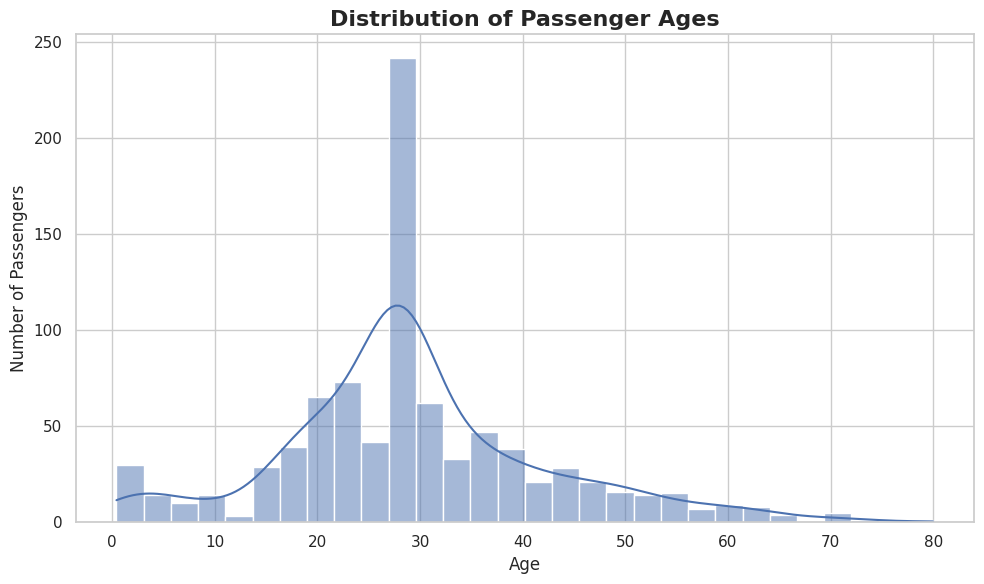

In [38]:
# ==========================================
# AGE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Age',
    bins=30,
    kde=True
)

plt.title(
    'Distribution of Passenger Ages',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

plt.tight_layout()
plt.show()

## 🔎 Finding — Passenger Age Distribution

The age distribution shows that the Titanic passenger population
contained a larger concentration of young and middle-aged passengers,
while relatively fewer passengers were elderly.

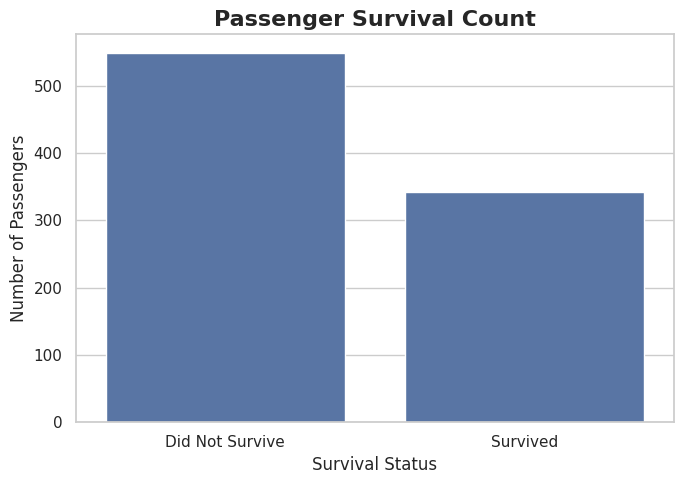

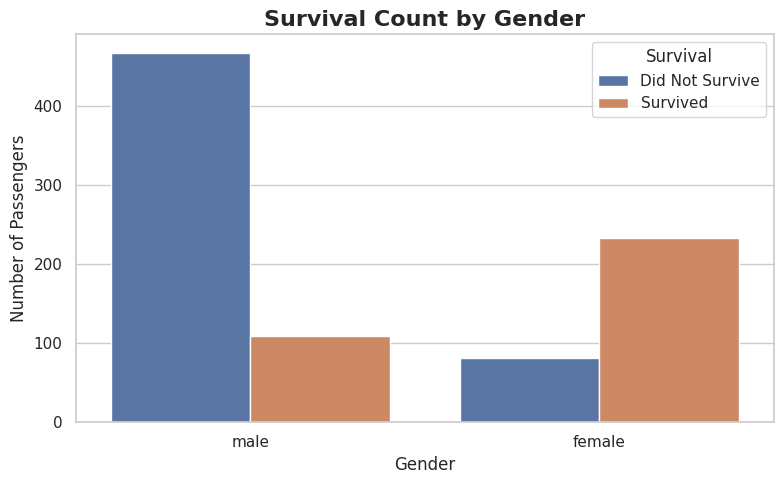

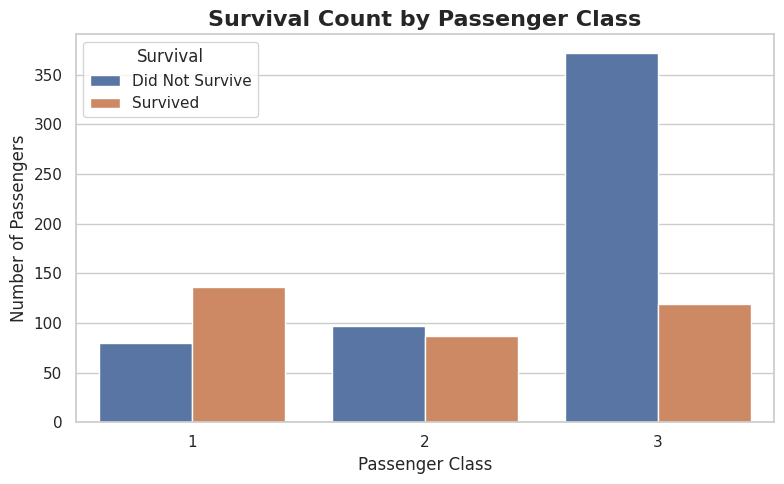

In [39]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='Survived'
)

plt.title(
    'Passenger Survival Count',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')

plt.xticks(
    [0, 1],
    ['Did Not Survive', 'Survived']
)

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title(
    'Survival Count by Gender',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.legend(
    title='Survival',
    labels=['Did Not Survive', 'Survived']
)

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title(
    'Survival Count by Passenger Class',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.legend(
    title='Survival',
    labels=['Did Not Survive', 'Survived']
)

plt.tight_layout()
plt.show()


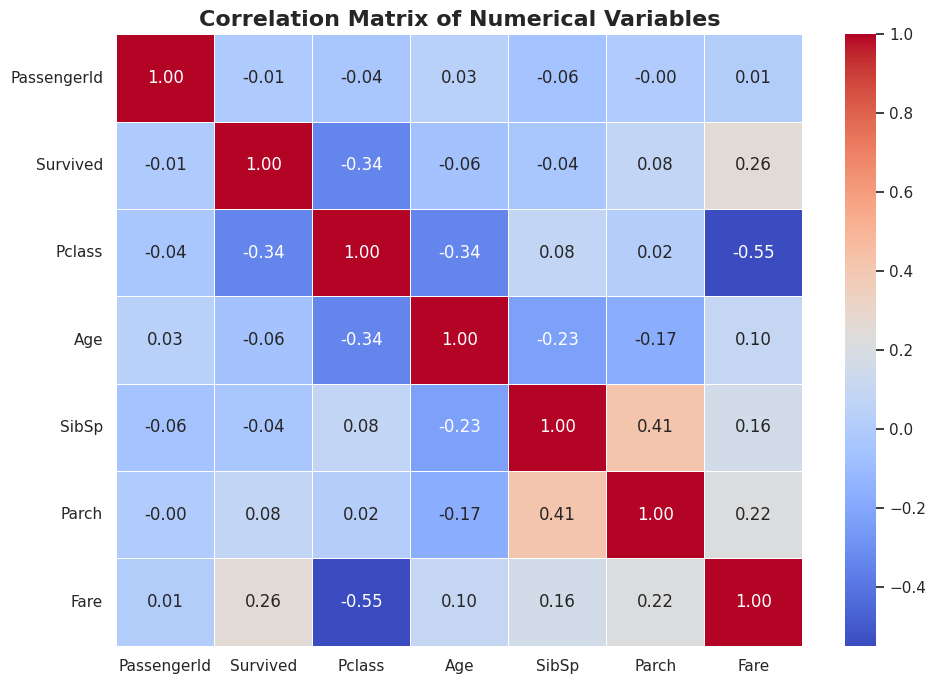

In [40]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

numeric_columns = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Correlation Matrix of Numerical Variables',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [41]:
# ==========================================
# SUMMARY TABLE
# ==========================================

summary = pd.DataFrame({
    'Analysis': [
        'Overall Survival',
        'Female Survival',
        'Male Survival',
        '1st Class Survival',
        '2nd Class Survival',
        '3rd Class Survival'
    ],
    'Survival Rate (%)': [
        df['Survived'].mean() * 100,
        df[df['Sex'] == 'female']['Survived'].mean() * 100,
        df[df['Sex'] == 'male']['Survived'].mean() * 100,
        df[df['Pclass'] == 1]['Survived'].mean() * 100,
        df[df['Pclass'] == 2]['Survived'].mean() * 100,
        df[df['Pclass'] == 3]['Survived'].mean() * 100
    ]
})

summary['Survival Rate (%)'] = summary['Survival Rate (%)'].round(2)

summary

,Analysis,Survival Rate (%)
0,Overall Survival,38.38
1,Female Survival,74.20
2,Male Survival,18.89
3,1st Class Survival,62.96
4,2nd Class Survival,47.28
5,3rd Class Survival,24.24


# 💡 Key Insights

### 1. Gender
Female passengers had a considerably higher survival rate than
male passengers.

### 2. Passenger Class
Passenger class was strongly associated with survival. First-class
passengers had better survival outcomes than passengers in lower
classes.

### 3. Age
Survival rates differed between age groups, indicating that age was
also associated with survival outcomes.

### 4. Data Quality
The original dataset contained missing values. Data cleaning was
therefore an important step before performing the analysis.

### 5. Visualization
Bar charts and histograms made it easier to identify and communicate
important patterns in the dataset.

# 📝 Conclusion

This project successfully analyzed the Titanic passenger dataset
using Python and popular data analysis libraries.

The dataset was inspected and cleaned by identifying missing values
and applying appropriate handling techniques. Exploratory analysis
was then performed to understand passenger survival patterns.

The results demonstrated noticeable differences in survival based on
gender and passenger class. Survival rates also varied across age
groups. Data visualizations provided an effective way to communicate
these patterns and supported the interpretation of the results.

Overall, this project provided practical experience in data
cleaning, exploratory data analysis, grouping, statistical
summarization, and data visualization using Pandas, Matplotlib,
and Seaborn.

# 📚 References

1. Kaggle — Titanic Dataset
2. Pandas Documentation
3. Matplotlib Documentation
4. Seaborn Documentation
5. Google Colab Documentation